In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("European_Bank.csv")

In [56]:
df.head(20)

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,TenureGroup
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,New
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,New
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Long Term
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,New
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,New
5,2025,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,Long Term
6,2025,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0,Mid Term
7,2025,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,Mid Term
8,2025,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,Mid Term
9,2025,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,New


In [6]:
print(df.isnull().sum())
print(df.describe())

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
          Year    CustomerId   CreditScore           Age        Tenure  \
count  10000.0  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    2025.0  1.569094e+07    650.528800     38.921800      5.012800   
std        0.0  7.193619e+04     96.653299     10.487806      2.892174   
min     2025.0  1.556570e+07    350.000000     18.000000      0.000000   
25%     2025.0  1.562853e+07    584.000000     32.000000      3.000000   
50%     2025.0  1.569074e+07    652.000000     37.000000      5.000000   
75%     2025.0  1.575323e+07    718.000000     44.000000      7.000000   
max     2025.0  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumO

In [7]:
import matplotlib.pyplot as plt

In [8]:
churn_rate=(df['Exited'].mean()*100)
print("churn rate is : ",churn_rate)

churn rate is :  20.369999999999997


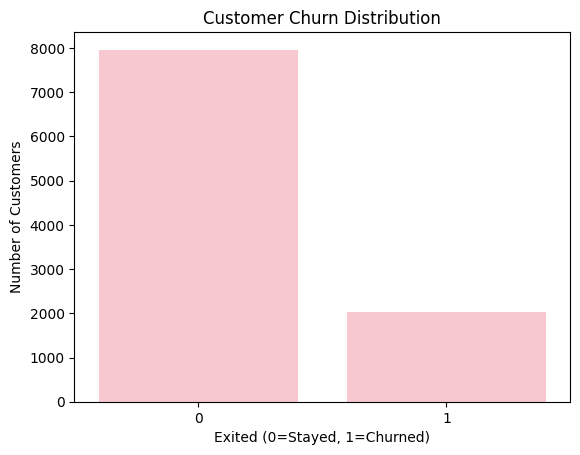

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Exited', data=df,color='pink')
plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0=Stayed, 1=Churned)")
plt.ylabel("Number of Customers")
plt.show()

Exited
0    7963
1    2037
Name: count, dtype: int64


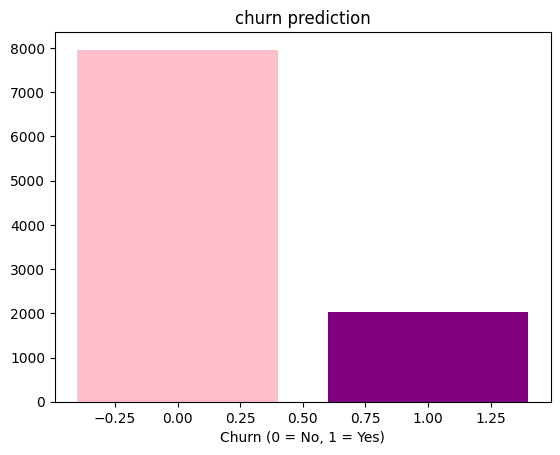

In [28]:
count=(df['Exited'].value_counts())
print(count)
x = count.index.tolist()
y = count.values.tolist()
plt.bar(x,y,color=["pink",'purple'])
plt.title("churn prediction")
plt.xlabel('Churn (0 = No, 1 = Yes)')

plt.plot()
plt.show()

In [37]:
#churn by gender
gender_churn = pd.crosstab(
    df['Gender'],
    df['Exited'],
    normalize='index'
)*100

print(gender_churn)

Exited          0          1
Gender                      
Female  74.928461  25.071539
Male    83.544072  16.455928


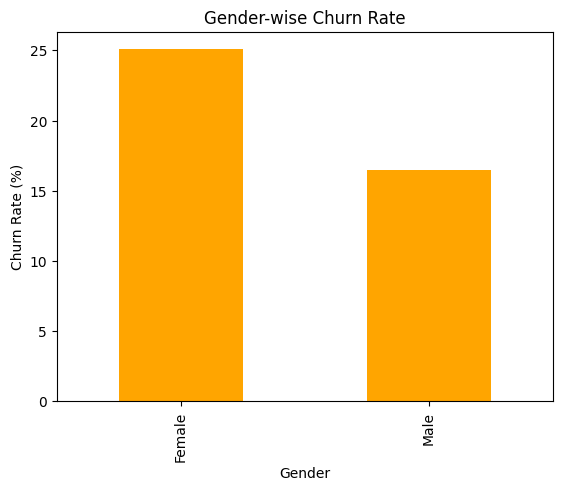

In [30]:
gender_churn = df.groupby('Gender')['Exited'].mean()*100

gender_churn.plot(kind='bar',color='orange')
plt.title("Gender-wise Churn Rate")
plt.ylabel("Churn Rate (%)")
plt.show()

In [13]:
#churn by country
country_churn = pd.crosstab(
    df['Geography'],
    df['Exited'],
    normalize='index'
)*100

print(country_churn)

Exited             0          1
Geography                      
France     83.845233  16.154767
Germany    67.556796  32.443204
Spain      83.326605  16.673395


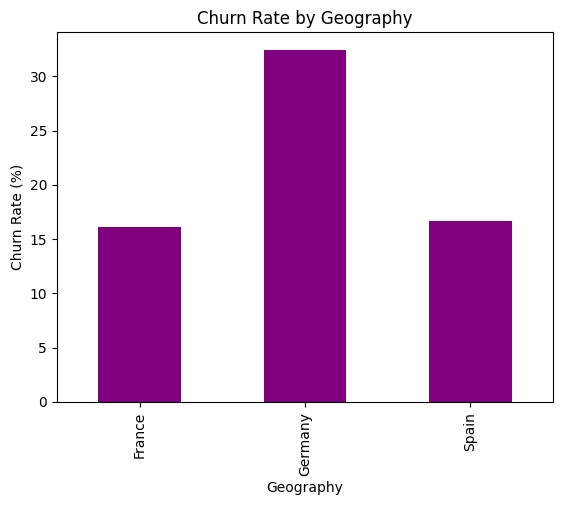

In [17]:
geo_churn = df.groupby('Geography')['Exited'].mean()*100

geo_churn.plot(kind='bar',color='purple')
plt.title("Churn Rate by Geography")
plt.ylabel("Churn Rate (%)")
plt.show()

In [41]:
#churn by tenure
tenure_churn = pd.crosstab(
    df['Tenure'],
    df['Exited'],
    normalize='index'
)*100

print(tenure_churn)

Exited          0          1
Tenure                      
0       76.997579  23.002421
1       77.584541  22.415459
2       80.820611  19.179389
3       78.889990  21.110010
4       79.474216  20.525784
5       79.347826  20.652174
6       79.731127  20.268873
7       82.782101  17.217899
8       80.780488  19.219512
9       78.353659  21.646341
10      79.387755  20.612245


In [14]:
#coustomer segmentation:
#1.geography segmentation

geo_churn=pd.crosstab(df['Geography'],df['Exited'],normalize='index')*100
print(geo_churn)


Exited             0          1
Geography                      
France     83.845233  16.154767
Germany    67.556796  32.443204
Spain      83.326605  16.673395


In [16]:
#2.age segmentation:
bins=[18,30,45,60,100]
labels=['young','Adult','Middle Age','senior']
df['AgeGroup']=pd.cut(df['Age'],bins=bins,labels=labels)

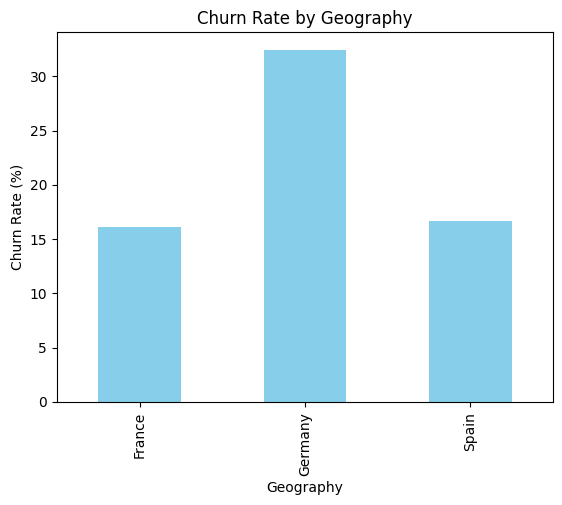

In [23]:
geo_churn = df.groupby('Geography')['Exited'].mean()*100

geo_churn.plot(kind='bar',color='skyblue')
plt.title("Churn Rate by Geography")
plt.ylabel("Churn Rate (%)")
plt.show()

In [17]:
age_churn = pd.crosstab(
    df['AgeGroup'],
    df['Exited'],
    normalize='index'
)*100

print(age_churn)

Exited              0          1
AgeGroup                        
young       92.497431   7.502569
Adult       84.259416  15.740584
Middle Age  48.876746  51.123254
senior      75.215517  24.784483


In [19]:
#3.credit score segmentation
def credit_segment(score):
    if score<500:
        return 'Low'
    elif score<700:
        return 'Medium'
    else:
        return 'High'

df['CreditCategory']=df['CreditScore'].apply(credit_segment)
pd.crosstab(
    df['CreditCategory'],
    df['Exited'],
    normalize='index'
)*100

Exited,0,1
CreditCategory,,
High,80.177891,19.822109
Low,76.265823,23.734177
Medium,79.694534,20.305466


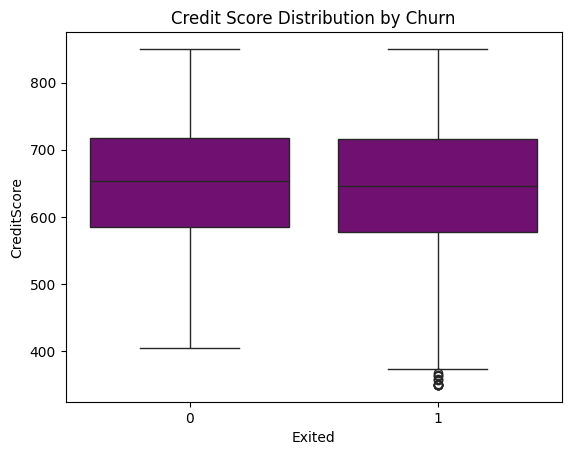

In [35]:
sns.boxplot(
    x='Exited',
    y='CreditScore',
    color='purple',
    data=df
)

plt.title("Credit Score Distribution by Churn")
plt.show()

In [22]:
#4.Balanced Segmentation
def balance_group(balance):
    if balance==0:
        return 'Zero Balance'
    elif balance<100000:
        return 'Low Balance'
    else:
        return 'High Balance'

df['BalanceGroup']=df['Balance'].apply(balance_group)
pd.crosstab(
    df['BalanceGroup'],
    df['Exited'],
    normalize='index'
)*100

Exited,0,1
BalanceGroup,,
High Balance,74.765576,25.234424
Low Balance,79.419192,20.580808
Zero Balance,86.176389,13.823611


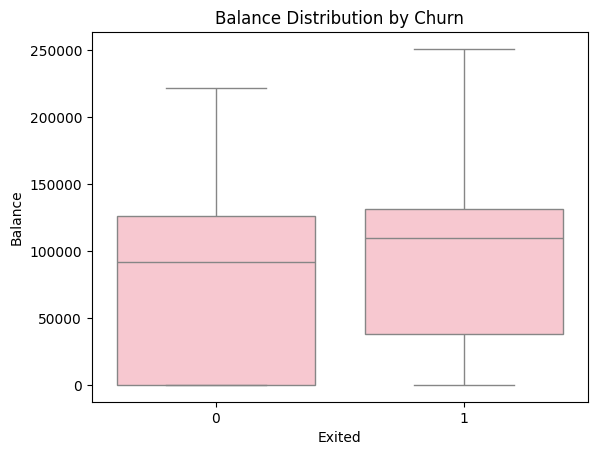

In [37]:
sns.boxplot(
    x='Exited',
    y='Balance',
    color='pink',
    data=df
)

plt.title("Balance Distribution by Churn")
plt.show()

In [25]:
#5.Tenure Segmentation
def tenure_group(t):
    if t<=3:
        return 'New'
    elif t<=7:
        return 'Mid Term'
    else:
        return 'Long Term'

df['TenureGroup']=df['Tenure'].apply(tenure_group)
pd.crosstab(
    df['TenureGroup'],
    df['Exited'],
    normalize='index'
)*100
    

Exited,0,1
TenureGroup,,
Long Term,79.551821,20.448179
Mid Term,80.355355,19.644645
New,78.858773,21.141227


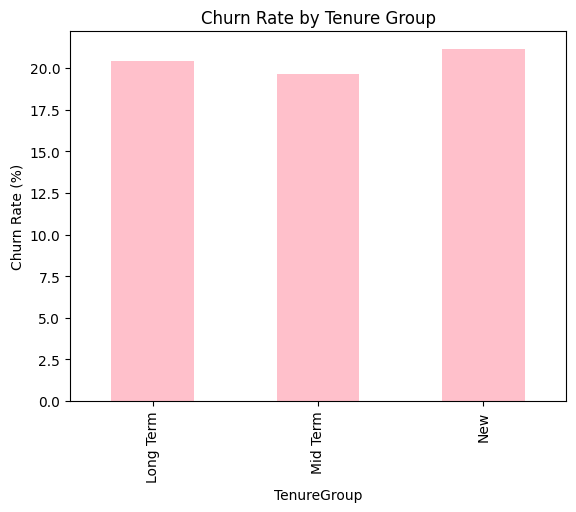

In [32]:
tenure_churn = df.groupby(
    'TenureGroup'
)['Exited'].mean()*100

tenure_churn.plot(kind='bar',color='pink')
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.show()

In [24]:
# GENDER VS CHURN:
pd.crosstab(
    df['Gender'],
    df['Exited'],
    normalize='index'
)*100


Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


In [38]:
#ACTIVE MEMBER VS CHURN:
pd.crosstab(
    df['IsActiveMember'],
    df['Exited'],
    normalize='index'
)*100


Exited,0,1
IsActiveMember,,
0,73.149103,26.850897
1,85.730926,14.269074


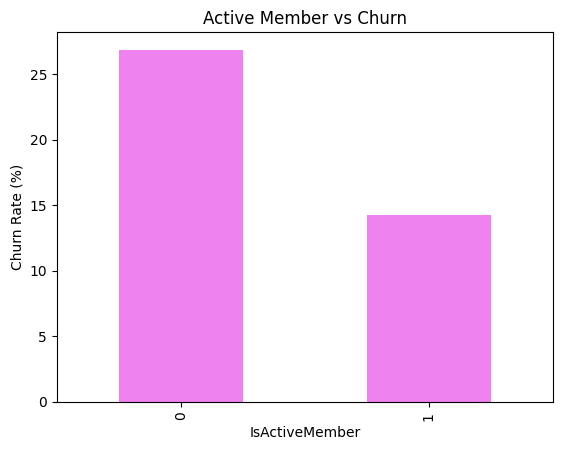

In [45]:
active_churn = df.groupby(
    'IsActiveMember'
)['Exited'].mean()*100

active_churn.plot(kind='bar',color='violet')
plt.title("Active Member vs Churn")
plt.ylabel("Churn Rate (%)")
plt.show()

In [26]:
# PRODUCT VS CHURN:
pd.crosstab(
    df['NumOfProducts'],
    df['Exited'],
    normalize='index'
)*100

Exited,0,1
NumOfProducts,,
1,72.285602,27.714398
2,92.418301,7.581699
3,17.293233,82.706767
4,0.000000,100.000000


In [27]:
premium = df[df['Balance'] > 100000]
premium['Exited'].mean()*100

np.float64(25.234423838299648)

In [28]:
# Money loss due to churn:
lost_balance = df[df['Exited']==1]['Balance'].sum()

print(lost_balance)

185588094.63


In [30]:
!pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: >

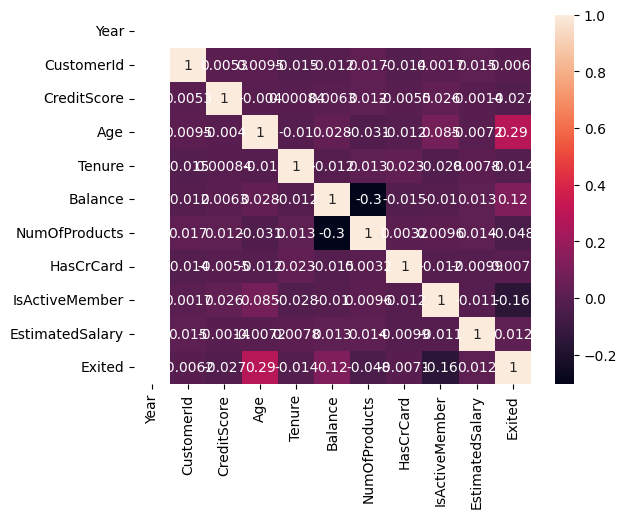

In [32]:
import seaborn as sns

corr = df.corr(numeric_only=True)

sns.heatmap(corr,annot=True)

In [35]:
# Overall churn Rate:
total_customers = len(df)
churned_customers = df['Exited'].sum()

churn_rate = (churned_customers / total_customers) * 100

print("Overall Churn Rate is :",churn_rate)

Overall Churn Rate is : 20.369999999999997


In [37]:
#Segment CHurn Rate:
pd.crosstab(
    df['Geography'],
    df['Exited'],
    normalize='index'
)*100


Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


25.234423838299648


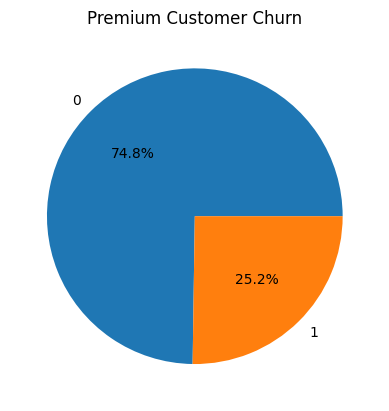

In [52]:
#High Value Churn Ratio:
premium = df[df['Balance'] > 100000]
premium_churn = premium['Exited'].mean()*100
print(premium_churn)


premium = df[df['Balance'] > 100000]

premium.groupby('Exited').size().plot(
    kind='pie',
    autopct='%1.1f%%',
    
)

plt.title("Premium Customer Churn")
plt.ylabel("")
plt.show()


Exited             0          1
Geography                      
France     83.845233  16.154767
Germany    67.556796  32.443204
Spain      83.326605  16.673395


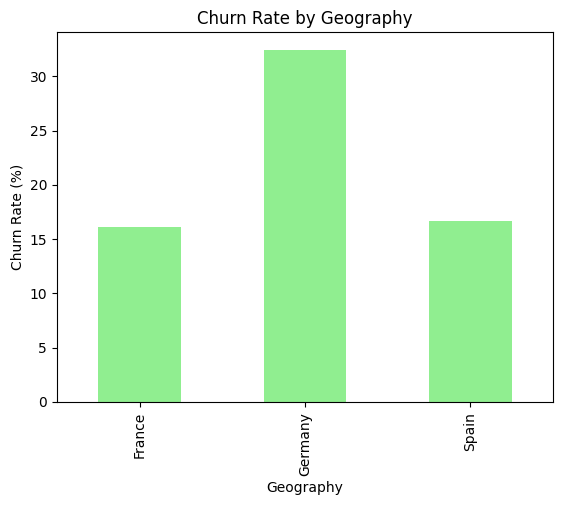

In [55]:
#Which country has highest churn Risk(Geaographic ridk index):
geo_risk = pd.crosstab(
    df['Geography'],
    df['Exited'],
    normalize='index'
)*100

print(geo_risk)

geo_churn = df.groupby('Geography')['Exited'].mean()*100

geo_churn.plot(kind='bar',color='lightgreen')
plt.title("Churn Rate by Geography")
plt.ylabel("Churn Rate (%)")
plt.show()

In [40]:
#Revenue at Risk:
lost_balance = df[df['Exited']==1]['Balance'].sum()

print(lost_balance)

185588094.63


In [41]:
#Average Balance of churned coustomer:
avg_balance = df[df['Exited']==1]['Balance'].mean()

print(avg_balance)

91108.53933726068


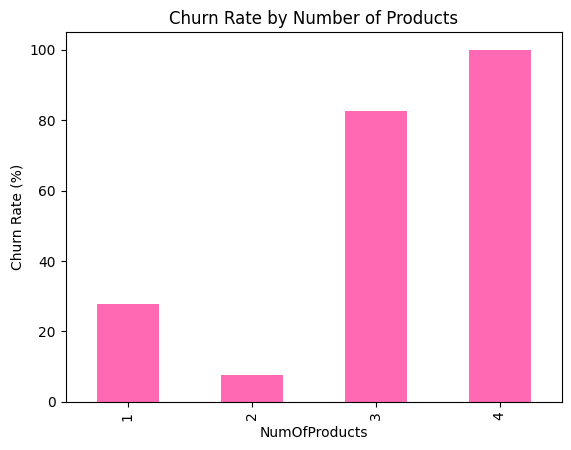

In [62]:
#number of product analysis:
product_churn = df.groupby(
    'NumOfProducts'
)['Exited'].mean()*100

product_churn.plot(kind='bar',color='hotpink')
plt.title("Churn Rate by Number of Products")
plt.ylabel("Churn Rate (%)")
plt.show()

In [42]:
#Average Tenure of churned cousomers:
avg_tenure = df[df['Exited']==1]['Tenure'].mean()

print(avg_tenure)

4.932744231713304
